In [1]:
print("开始学习第2章!")

开始学习第2章!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import mglearn

In [4]:
!pip install mglearn

   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/581.4 kB ? eta -:--:--
   ---------------------------------------- 581.4/581.4 kB 4.5 MB/s  0:00:00


In [9]:
print("="*50)
print("监督学习的两大类型")
print("="*50)

from sklearn.datasets import load_iris
iris = load_iris()
print("\n【分类问题】预测鸢尾花的品种")
print("可能的输出:",iris.target_names)


监督学习的两大类型

【分类问题】预测鸢尾花的品种
可能的输出: ['setosa' 'versicolor' 'virginica']


In [12]:
print("\n【回归问题示例】")
from sklearn.datasets import make_regression
X,y=make_regression(n_samples=100,n_features=1,noise=20,random_state=0)
print("回归问题：预测连续数值（比如房价、温度、销售额）")
print("示例数据：输入特征 shape={},目标值 shape={}".format(X.shape,y.shape))
print("前5个目标值：{}".format(y[:5]))



【回归问题示例】
回归问题：预测连续数值（比如房价、温度、销售额）
示例数据：输入特征 shape=(100, 1),目标值 shape=(100,)
前5个目标值：[-24.67192895   1.2842068    6.06033557   1.78147734 -33.77202985]



过拟合 vs 欠拟合 演示


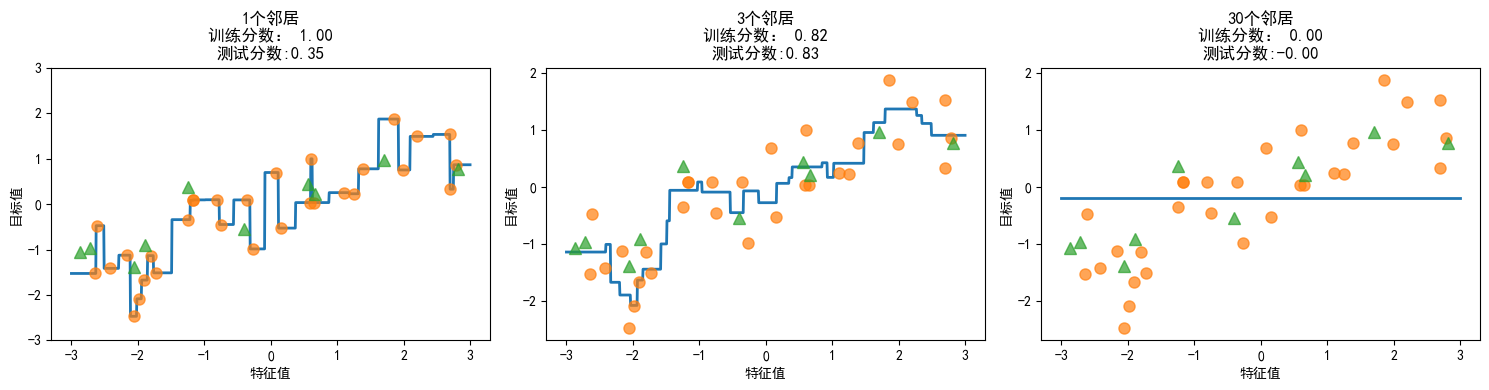

In [18]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("\n"+"="*50)
print("过拟合 vs 欠拟合 演示")
print("=" * 50)

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

X,y=mglearn.datasets.make_wave(n_samples=40)

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

fig,axes = plt.subplots(1,3,figsize=(15,4))

for n_neighbors,ax in zip([1,3,30],axes):
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(X_train, y_train)

    X_plot = np.linspace(-3,3,1000).reshape(-1,1)
    y_plot =reg.predict(X_plot)

    ax.plot(X_plot,y_plot,label='预测曲线',linewidth=2)
    ax.plot(X_train,y_train,'o',label='训练数据',alpha=0.7,markersize=8)
    ax.plot(X_test,y_test,'^',label='测试数据',alpha=0.7,markersize=8)
    ax.set_title(f'{n_neighbors}个邻居\n训练分数： {reg.score(X_train,y_train):.2f}\n测试分数:{reg.score(X_test,y_test):.2f}')
    ax.set_xlabel('特征值')
    ax.set_ylabel('目标值')

axes[0].set_ylim(-3,3)
plt.tight_layout()
plt.show()
    

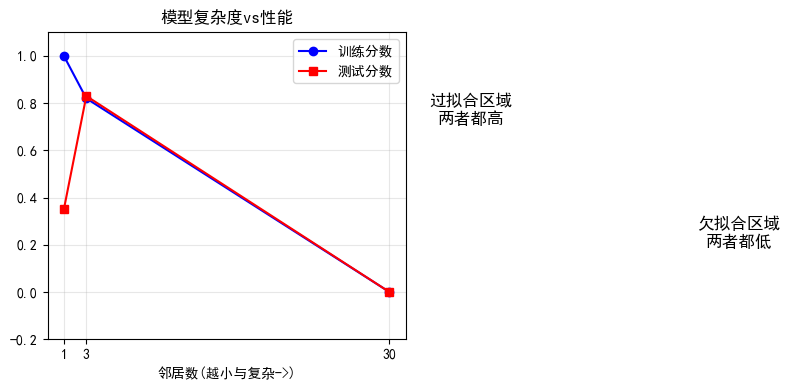

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot([1,3,30],[1.00,0.82,0.00],'o-',label='训练分数',color='blue')
plt.plot([1,3,30],[0.35,0.83,-0.00],'s-',label='测试分数',color='red')
plt.xticks([1,3,30])
plt.ylim(-0.2,1.1)
plt.xlabel('邻居数(越小与复杂->)')
plt.title('模型复杂度vs性能')
plt.legend()
plt.grid(True,alpha=0.3)

plt.subplot(1,3,2)
plt.text(0.1,0.7,'过拟合区域\n两者都高',fontsize=12,ha='center')
plt.text(0.85,0.3,'欠拟合区域\n两者都低',fontsize=12,ha='center')
plt.xlim(0,1)
plt.ylim(0,1)
plt.axis('off')

plt.tight_layout()
plt.show()